In [ ]:
import numpy as np
import cv2
import tensorflow as tf
import os
import matplotlib.pyplot as plt
import random
from sklearn.model_selection import train_test_split
from glob  import glob
import fnmatch
import collections
print(tf.__version__)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import *
from tensorflow.keras import regularizers,constraints,initializers
from tensorflow.keras.optimizers import *
from tensorflow.keras.callbacks import *

2.20.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train_path = '/content/drive/MyDrive/KMC_LiverGrading-20260309T090507Z-3-001/KMC_LiverGrading/Training'
val_path = '/content/drive/MyDrive/KMC_LiverGrading-20260309T090507Z-3-001/KMC_LiverGrading/Validation'
test_path = '/content/drive/MyDrive/KMC_LiverGrading-20260309T090507Z-3-001/KMC_LiverGrading/Test'

In [ ]:
number_train_image= train_generator.n
number_test_image=test_generator.n
number_val=
print(number_train_image)
print(number_test_image)


280
2549


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Concatenate, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import InceptionV3, DenseNet121


image_input = Input(shape=(224, 224, 3))



inception_base = InceptionV3(weights='imagenet', include_top=False, input_tensor=image_input)


for layer in inception_base.layers[:249]:
    layer.trainable = False


inception_features = GlobalAveragePooling2D()(inception_base.output)



densenet_base = DenseNet121(weights='imagenet', include_top=False, input_tensor=image_input)

for layer in densenet_base.layers[:313]:
    layer.trainable = False


densenet_features = GlobalAveragePooling2D()(densenet_base.output)



fused_features = Concatenate()([inception_features, densenet_features])



x = Dense(256, activation='relu')(fused_features)
x = Dropout(0.5)(x)


predictions = Dense(no_of_classes, activation='softmax')(x)



hybrid_model = Model(inputs=image_input, outputs=predictions)


hybrid_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Your new hybrid model is ready to train!")

Your new hybrid model is ready to train!


In [ ]:

history = hybrid_model.fit(
    train_generator,
    validation_data= validation_generator,
    epochs=20,
    batch_size=32,
    verbose=1

)


Epoch 1/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 612s 4s/step - accuracy: 0.9435 - loss: 0.1573 - val_accuracy: 0.8500 - val_loss: 0.4555
Epoch 2/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 24s 151ms/step - accuracy: 0.9800 - loss: 0.0682 - val_accuracy: 0.8821 - val_loss: 0.4159
Epoch 3/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 23s 143ms/step - accuracy: 0.9769 - loss: 0.0643 - val_accuracy: 0.8786 - val_loss: 0.4417
Epoch 4/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 24s 149ms/step - accuracy: 0.9867 - loss: 0.0355 - val_accuracy: 0.8571 - val_loss: 0.5624
Epoch 5/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 23s 143ms/step - accuracy: 0.9906 - loss: 0.0321 - val_accuracy: 0.8929 - val_loss: 0.5862
Epoch 6/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 41s 146ms/step - accuracy: 0.9898 - loss: 0.0337 - val_accuracy: 0.9071 - val_loss: 0.2838
Epoch 7/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 24s 146ms/step - accuracy: 0.9914 - loss: 0.0246 - val_accuracy: 0.9179 - val_loss: 0.2450
Epoch 8/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 24s 148ms/step - accuracy: 0.9957 - loss: 0.0

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix


predictions = hybrid_model.predict(validation_generator)
predicted_classes = np.argmax(predictions, axis=1)


true_classes = validation_generator.classes
class_labels = list(validation_generator.class_indices.keys())


print(classification_report(true_classes, predicted_classes, target_names=class_labels))

18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 226ms/step
              precision    recall  f1-score   support

      grade0       0.20      0.20      0.20        70
      grade1       0.36      0.44      0.39        80
      grade2       0.32      0.25      0.28        80
      grade3       0.18      0.18      0.18        50

    accuracy                           0.28       280
   macro avg       0.26      0.27      0.26       280
weighted avg       0.28      0.28      0.27       280



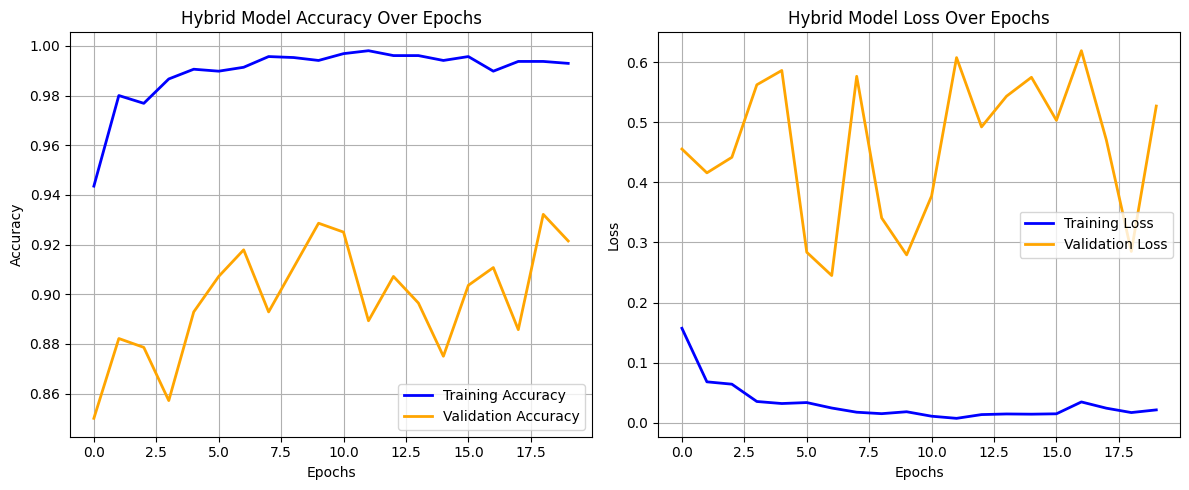

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Hybrid Model Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)


plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
plt.title('Hybrid Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
batch_size = 16

img_height = 224
img_width = 224
no_of_classes = 4

In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    vertical_flip=True
)

import os

if not os.path.exists(train_path):
    print(f"Error: Training path does not exist: {train_path}")

else:
    train_generator = datagen.flow_from_directory(
        train_path,
        target_size=(img_height,img_width),
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=True
    )

if not os.path.exists(val_path):
    print(f"Error: Validation path does not exist: {val_path}")
else:
    validation_generator = datagen.flow_from_directory(
        val_path,
        target_size=(img_height,img_width),
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=True
    )

if not os.path.exists(test_path):
    print(f"Error: Test path does not exist: {test_path}")
else:
    test_generator = datagen.flow_from_directory(
        test_path,
        target_size=(img_height,img_width),
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=False
    )


if 'train_generator' in locals():
    print(train_generator.class_indices)

Found 2549 images belonging to 4 classes.
Found 280 images belonging to 4 classes.
Found 280 images belonging to 4 classes.
{'grade0': 0, 'grade1': 1, 'grade2': 2, 'grade3': 3}


In [ ]:



  base_model = tf.keras.applications.VGG19(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256,activation='relu')(x)

pred = Dense(no_of_classes,activation='softmax')(x)

model_vgg = Model(inputs=base_model.input,outputs=pred)

model_vgg.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_vgg.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 20,156,740 (76.89 MB)

 Trainable params: 20,156,740 (76.89 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_vgg = model_vgg.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20
)
model_vgg.save("vgg19_liver_model.h5")

Epoch 1/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 109s 497ms/step - accuracy: 0.2566 - loss: 2.3225 - val_accuracy: 0.2857 - val_loss: 1.3833
Epoch 2/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 52s 325ms/step - accuracy: 0.2448 - loss: 1.3861 - val_accuracy: 0.2857 - val_loss: 1.3888
Epoch 3/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 52s 325ms/step - accuracy: 0.2566 - loss: 1.3853 - val_accuracy: 0.2857 - val_loss: 1.3885
Epoch 4/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 52s 324ms/step - accuracy: 0.2581 - loss: 1.3852 - val_accuracy: 0.2857 - val_loss: 1.3885
Epoch 5/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 53s 329ms/step - accuracy: 0.2628 - loss: 1.3853 - val_accuracy: 0.2857 - val_loss: 1.3885
Epoch 6/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 52s 323ms/step - accuracy: 0.2534 - loss: 1.3852 - val_accuracy: 0.1786 - val_loss: 1.3893
Epoch 7/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 52s 325ms/step - accuracy: 0.2601 - loss: 1.3852 - val_accuracy: 0.2857 - val_loss: 1.3884
Epoch 8/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 52s 323ms/step - accuracy: 0.2530 - loss: 

In [ ]:

pred_vgg = model_vgg.predict(test_generator)


y_pred_vgg = np.argmax(pred_vgg, axis=1)


18/18 ━━━━━━━━━━━━━━━━━━━━ 174s 10s/step


In [ ]:
print(pred_vgg)

[[0.22502528 0.25144336 0.26374012 0.25979128]
 [0.22502528 0.25144336 0.26374012 0.25979128]
 [0.22502528 0.25144336 0.26374012 0.25979128]
 ...
 [0.22502528 0.25144336 0.26374012 0.25979128]
 [0.22502528 0.25144336 0.26374012 0.25979128]
 [0.22502528 0.25144336 0.26374012 0.25979128]]


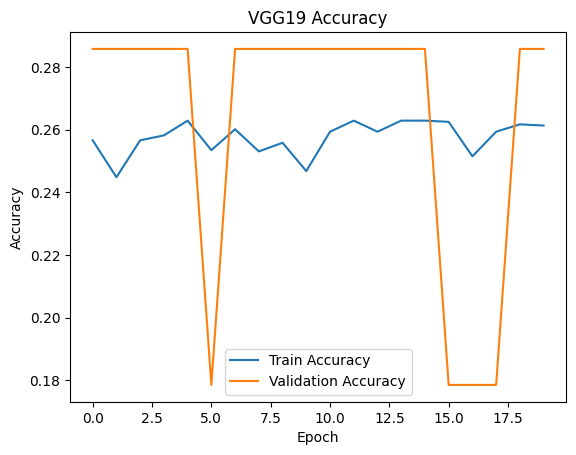

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(history_vgg.history['accuracy'])
plt.plot(history_vgg.history['val_accuracy'])

plt.title("VGG19 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train Accuracy","Validation Accuracy"])

plt.show()

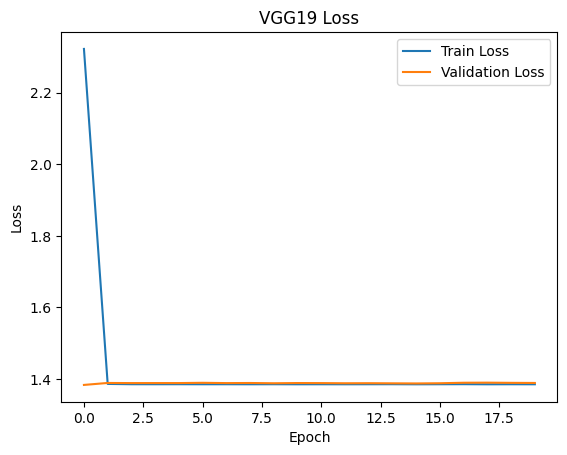

In [ ]:
plt.figure()

plt.plot(history_vgg.history['loss'])
plt.plot(history_vgg.history['val_loss'])

plt.title("VGG19 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train Loss","Validation Loss"])

plt.show()

In [ ]:
print("VGG19 Test Accuracy")
model_vgg.evaluate(test_generator)

VGG19 Test Accuracy
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 132ms/step - accuracy: 0.2857 - loss: 1.3888


[1.388814926147461, 0.2857142984867096]

In [ ]:



base_model = tf.keras.applications.ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256,activation='relu')(x)

pred = Dense(no_of_classes,activation='softmax')(x)

model_resnet = Model(inputs=base_model.input,outputs=pred)

model_resnet.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_resnet.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 24,060,164 (91.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
history_resnet = model_resnet.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20
)
model_resnet.save("resnet_liver_model.h5")

Epoch 1/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 144s 412ms/step - accuracy: 0.7638 - loss: 0.7011 - val_accuracy: 0.2500 - val_loss: 37.9140
Epoch 2/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 29s 181ms/step - accuracy: 0.8599 - loss: 0.3526 - val_accuracy: 0.2500 - val_loss: 25.3071
Epoch 3/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 29s 178ms/step - accuracy: 0.8894 - loss: 0.2961 - val_accuracy: 0.1786 - val_loss: 2.1342
Epoch 4/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 28s 177ms/step - accuracy: 0.9007 - loss: 0.2426 - val_accuracy: 0.2500 - val_loss: 3.8460
Epoch 5/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 29s 178ms/step - accuracy: 0.9098 - loss: 0.2147 - val_accuracy: 0.2500 - val_loss: 7.3090
Epoch 6/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 29s 179ms/step - accuracy: 0.8992 - loss: 0.2213 - val_accuracy: 0.2500 - val_loss: 4.8220
Epoch 7/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 29s 178ms/step - accuracy: 0.8866 - loss: 0.2838 - val_accuracy: 0.3250 - val_loss: 3.1749
Epoch 8/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 29s 180ms/step - accuracy: 0.8890 - loss

In [ ]:

pred_resnet = model_resnet.predict(test_generator)


y_pred_resnet = np.argmax(pred_resnet, axis=1)


18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 445ms/step


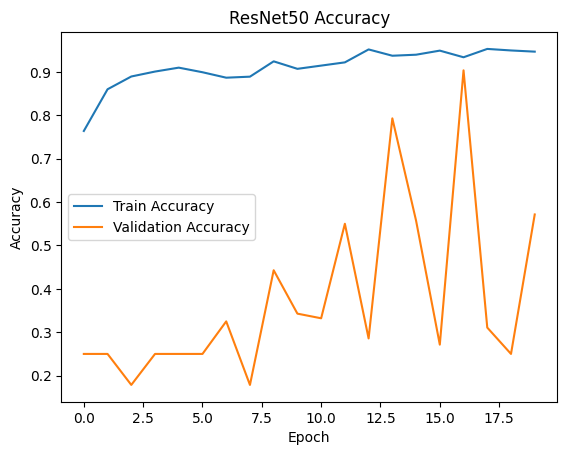

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(history_resnet.history['accuracy'])
plt.plot(history_resnet.history['val_accuracy'])

plt.title("ResNet50 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train Accuracy","Validation Accuracy"])

plt.show()

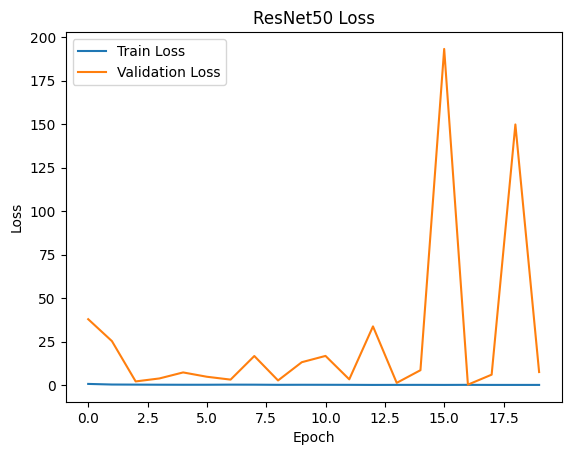

In [ ]:
plt.figure()

plt.plot(history_resnet.history['loss'])
plt.plot(history_resnet.history['val_loss'])

plt.title("ResNet50 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train Loss","Validation Loss"])

plt.show()

In [ ]:
print("Resnet Test Accuracy")
model_resnet.evaluate(test_generator)

Resnet Test Accuracy
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - accuracy: 0.5786 - loss: 7.4228


[7.422774791717529, 0.5785714387893677]

In [ ]:
base_model = tf.keras.applications.InceptionResNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)


for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(1024, activation='relu')(x)
x = Dense(512, activation='relu')(x)
x = Dense(256, activation='relu')(x)
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)

pred = Dense(no_of_classes, activation='softmax')(x)

model_inception = Model(inputs=base_model.input, outputs=pred)

from tensorflow.keras.optimizers import Adam

model_inception.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_inception.summary()

219055592/219055592 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_188 (Conv2D) │ (None, 111, 111,  │        864 │ input_layer_5[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 111, 111,  │         96 │ conv2d_188[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_188      │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_189 (Conv2D) │ (None, 109, 109,  │      9,216 │ activation_188[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_189[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_189      │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_190 (Conv2D) │ (None, 109, 109,  │     18,432 │ activation_189[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_190[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_190      │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 54, 54,    │          0 │ activation_190[0… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_191 (Conv2D) │ (None, 54, 54,    │      5,120 │ max_pooling2d_8[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_191[0][0]  │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_191      │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_192 (Conv2D) │ (None, 52, 52,    │    138,240 │ activation_191[0… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_192[0][0]  │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_192      │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 56,608,164 (215.94 MB)

 Trainable params: 2,271,428 (8.66 MB)

 Non-trainable params: 54,336,736 (207.28 MB)

In [ ]:
history_inception = model_inception.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20
)
model_inception.save("inception_liver_model.h5")

Epoch 1/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 90s 353ms/step - accuracy: 0.7811 - loss: 0.5423 - val_accuracy: 0.8214 - val_loss: 0.4093
Epoch 2/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 22s 135ms/step - accuracy: 0.9027 - loss: 0.2334 - val_accuracy: 0.8143 - val_loss: 0.4029
Epoch 3/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 23s 144ms/step - accuracy: 0.9247 - loss: 0.1749 - val_accuracy: 0.7964 - val_loss: 0.5265
Epoch 4/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 22s 136ms/step - accuracy: 0.9466 - loss: 0.1420 - val_accuracy: 0.8929 - val_loss: 0.3248
Epoch 5/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 23s 144ms/step - accuracy: 0.9514 - loss: 0.1170 - val_accuracy: 0.8607 - val_loss: 0.3188
Epoch 6/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 22s 136ms/step - accuracy: 0.9576 - loss: 0.0989 - val_accuracy: 0.8643 - val_loss: 0.4429
Epoch 7/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 23s 145ms/step - accuracy: 0.9553 - loss: 0.1063 - val_accuracy: 0.9143 - val_loss: 0.2754
Epoch 8/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 22s 138ms/step - accuracy: 0.9745 - loss: 0

In [ ]:

pred_inception= model_inception.predict(test_generator)


y_pred_inception = np.argmax(pred_inception, axis=1)


18/18 ━━━━━━━━━━━━━━━━━━━━ 28s 913ms/step


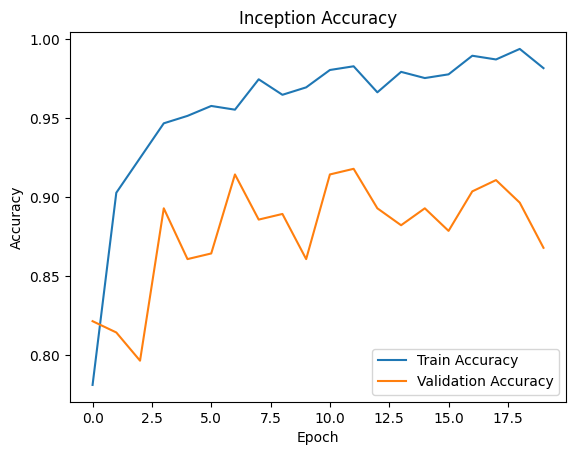

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(history_inception.history['accuracy'])
plt.plot(history_inception.history['val_accuracy'])

plt.title("Inception Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train Accuracy","Validation Accuracy"])

plt.show()

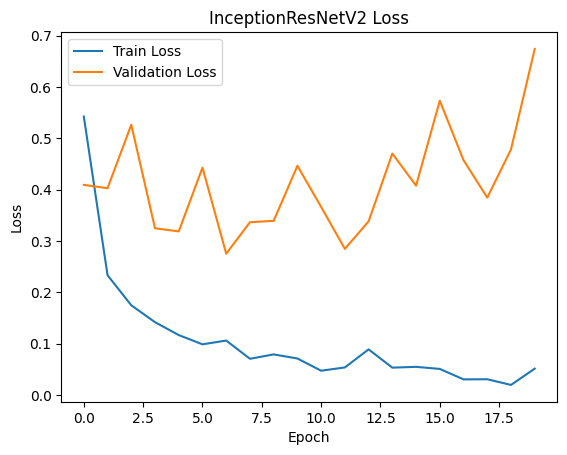

In [ ]:
plt.figure()

plt.plot(history_inception.history['loss'])
plt.plot(history_inception.history['val_loss'])

plt.title("InceptionResNetV2 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train Loss","Validation Loss"])

plt.show()

In [ ]:
print("InceptionResNet Test Accuracy")
model_inception.evaluate(test_generator)

InceptionResNet Test Accuracy
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 143ms/step - accuracy: 0.8286 - loss: 0.7238


[0.7238146066665649, 0.8285714387893677]

In [ ]:

import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score

In [ ]:



y_true = test_generator.classes

In [ ]:
pred_vgg = model_vgg.predict(test_generator)

y_pred_vgg = np.argmax(pred_vgg, axis=1)

print("VGG19 Accuracy:", accuracy_score(y_true, y_pred_vgg))

cm_vgg = confusion_matrix(y_true, y_pred_vgg)
print("VGG19 Confusion Matrix:\n", cm_vgg)

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step
VGG19 Accuracy: 0.2857142857142857
VGG19 Confusion Matrix:
 [[ 0  0 70  0]
 [ 0  0 80  0]
 [ 0  0 80  0]
 [ 0  0 50  0]]


In [ ]:
pred_resnet = model_resnet.predict(test_generator)

y_pred_resnet = np.argmax(pred_resnet, axis=1)

print("ResNet Accuracy:", accuracy_score(y_true, y_pred_resnet))

cm_resnet = confusion_matrix(y_true, y_pred_resnet)
print("ResNet Confusion Matrix:\n", cm_resnet)

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step
ResNet Accuracy: 0.5892857142857143
ResNet Confusion Matrix:
 [[70  0  0  0]
 [ 1  0 79  0]
 [ 0  0 80  0]
 [ 1  0 34 15]]


In [ ]:
pred_inception = model_inception.predict(test_generator)

y_pred_inception = np.argmax(pred_inception, axis=1)

print("Inception Accuracy:", accuracy_score(y_true, y_pred_inception))

cm_inception = confusion_matrix(y_true, y_pred_inception)
print("Inception Confusion Matrix:\n", cm_inception)

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step
Inception Accuracy: 0.8678571428571429
Inception Confusion Matrix:
 [[69  1  0  0]
 [ 0 71  5  4]
 [ 2 17 55  6]
 [ 0  2  0 48]]


In [ ]:
acc_vgg = accuracy_score(y_true, y_pred_vgg)
acc_resnet = accuracy_score(y_true, y_pred_resnet)
acc_inception = accuracy_score(y_true, y_pred_inception)

In [ ]:
cm_vgg = confusion_matrix(y_true, y_pred_vgg)
cm_resnet = confusion_matrix(y_true, y_pred_resnet)
cm_inception = confusion_matrix(y_true, y_pred_inception)

In [ ]:
import pandas as pd
comparison = pd.DataFrame({
    "Model": ["VGG19", "ResNet", "Inception"],
    "Accuracy": [acc_vgg, acc_resnet, acc_inception]
})

print(comparison)

       Model  Accuracy
0      VGG19  0.285714
1     ResNet  0.589286
2  Inception  0.867857


In [ ]:
test_generator.reset()

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score

# True labels
y_true = test_generator.classes

# VGG19
test_generator.reset()
pred_vgg = model_vgg.predict(test_generator)
y_pred_vgg = np.argmax(pred_vgg, axis=1)

# ResNet
test_generator.reset()
pred_resnet = model_resnet.predict(test_generator)
y_pred_resnet = np.argmax(pred_resnet, axis=1)

# Inception
test_generator.reset()
pred_inception = model_inception.predict(test_generator)
y_pred_inception = np.argmax(pred_inception, axis=1)

# Hybrid Model
test_generator.reset()
pred_hybrid = hybrid_model.predict(test_generator)
y_pred_hybrid = np.argmax(pred_hybrid, axis=1)

# Accuracy
acc_vgg = accuracy_score(y_true, y_pred_vgg)
acc_resnet = accuracy_score(y_true, y_pred_resnet)
acc_inception = accuracy_score(y_true, y_pred_inception)
acc_hybrid = accuracy_score(y_true, y_pred_hybrid)

print("VGG19 Accuracy:", acc_vgg)
print("ResNet Accuracy:", acc_resnet)
print("Inception Accuracy:", acc_inception)
print("Hybrid Model Accuracy:", acc_hybrid)

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 132ms/step
VGG19 Accuracy: 0.2857142857142857
ResNet Accuracy: 0.5857142857142857
Inception Accuracy: 0.8464285714285714
Hybrid Model Accuracy: 0.8785714285714286


In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["VGG19", "ResNet", "Inception","hybrid_Model"],
    "Accuracy": [acc_vgg, acc_resnet, acc_inception,acc_hybrid]
})

print(comparison)

          Model  Accuracy
0         VGG19  0.285714
1        ResNet  0.585714
2     Inception  0.846429
3  hybrid_Model  0.878571


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix,classification_report

# Assuming y_true is already defined from test_generator.classes
# Assuming y_pred_vgg, y_pred_resnet, y_pred_inception, y_pred_hybrid are already defined

print("Confusion Matrix for VGG19:")
cm_vgg = confusion_matrix(y_true, y_pred_vgg)
print(cm_vgg)
print("\n")

print("Confusion Matrix for ResNet:")
cm_resnet = confusion_matrix(y_true, y_pred_resnet)
print(cm_resnet)
print("\n")

print("Confusion Matrix for InceptionResNetV2:")
cm_inception = confusion_matrix(y_true, y_pred_inception)
print(cm_inception)
print("\n")

print("Confusion Matrix for Hybrid Model:")
cm_hybrid = confusion_matrix(y_true, y_pred_hybrid)
print(cm_hybrid)

Confusion Matrix for VGG19:
[[ 0  0 70  0]
 [ 0  0 80  0]
 [ 0  0 80  0]
 [ 0  0 50  0]]


Confusion Matrix for ResNet:
[[70  0  0  0]
 [ 0  0 80  0]
 [ 0  0 80  0]
 [ 1  0 35 14]]


Confusion Matrix for InceptionResNetV2:
[[70  0  0  0]
 [ 0 68  6  6]
 [ 4 18 51  7]
 [ 0  2  0 48]]


Confusion Matrix for Hybrid Model:
[[70  0  0  0]
 [ 0 76  4  0]
 [ 0 25 54  1]
 [ 0  4  0 46]]


In [ ]:
from sklearn.metrics import classification_report

# Assuming y_true is defined as test_generator.classes
# Assuming y_pred_hybrid is defined from hybrid_model.predict(test_generator)
# Assuming class_labels is defined from test_generator.class_indices.keys()

print("Classification Report for Hybrid Model:")
print(classification_report(y_true, y_pred_hybrid, target_names=class_labels))

Classification Report for Hybrid Model:
              precision    recall  f1-score   support

      grade0       1.00      1.00      1.00        70
      grade1       0.72      0.95      0.82        80
      grade2       0.93      0.68      0.78        80
      grade3       0.98      0.92      0.95        50

    accuracy                           0.88       280
   macro avg       0.91      0.89      0.89       280
weighted avg       0.90      0.88      0.88       280



In [ ]:
from sklearn.metrics import classification_report

# Ensure y_true, y_pred_vgg, y_pred_resnet, y_pred_inception, and class_labels are defined

print("Classification Report for VGG19 Model:")
print(classification_report(y_true, y_pred_vgg, target_names=class_labels))
print("\n")

print("Classification Report for ResNet Model:")
print(classification_report(y_true, y_pred_resnet, target_names=class_labels))
print("\n")

print("Classification Report for Inception Model:")
print(classification_report(y_true, y_pred_inception, target_names=class_labels))


Classification Report for VGG19 Model:
              precision    recall  f1-score   support

      grade0       0.00      0.00      0.00        70
      grade1       0.00      0.00      0.00        80
      grade2       0.29      1.00      0.44        80
      grade3       0.00      0.00      0.00        50

    accuracy                           0.29       280
   macro avg       0.07      0.25      0.11       280
weighted avg       0.08      0.29      0.13       280



Classification Report for ResNet Model:
              precision    recall  f1-score   support

      grade0       0.99      1.00      0.99        70
      grade1       0.00      0.00      0.00        80
      grade2       0.41      1.00      0.58        80
      grade3       1.00      0.28      0.44        50

    accuracy                           0.59       280
   macro avg       0.60      0.57      0.50       280
weighted avg       0.54      0.59      0.49       280



Classification Report for Inception Model:
    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m